# 13. 効率的注意と状態空間モデル(付録)

## この章で分かること

- 標準注意の **$O(T^2)$** コストを実測する(07 章の続き)
- **FlashAttention**: 数式は同じまま IO を賢くして高速・省メモリにする(近似ではない)
- **線形注意**: softmax を特徴写像で置き換え **$O(T)$** にする(近似)
- **状態空間モデル (SSM / Mamba)**: 系列を線形回帰として $O(T)$ で処理する
- それぞれのトレードオフ

07 章で注意が長系列で重い($O(T^2)$)ことを見ました。本章はその先 —
**長いコンテキストをどう捌くか** の現代的な工夫を、小さなデモで概観します。

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from nn_textbook.models import linear_attention, linear_ssm_scan
from nn_textbook.training import set_seed

set_seed(0)
device = torch.device("cpu")
np.set_printoptions(precision=4, suppress=True)

## 1. Problem — 注意は系列長の 2 乗で重くなる

注意行列 $\mathrm{softmax}(QK^\top/\sqrt{d})$ は $T \times T$。系列長 $T$ を倍にすると、
計算もメモリも **4 倍**($O(T^2)$)。これがコンテキスト長の壁の正体です。
標準注意の 1 回の計算時間を、$T$ を変えながら実測します。

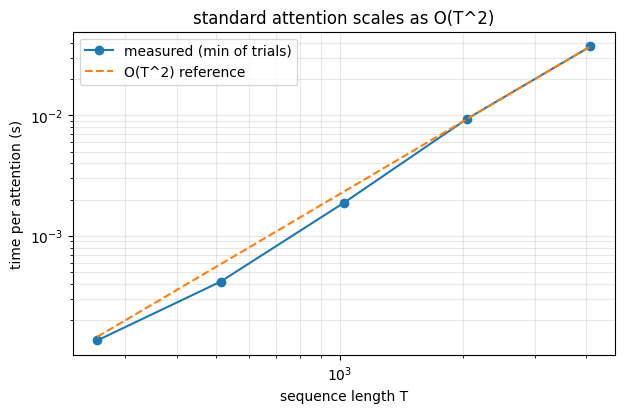

T=  256:    0.14 ms
T=  512:    0.42 ms
T= 1024:    1.88 ms
T= 2048:    9.38 ms
T= 4096:   37.31 ms


In [2]:
# Measure attention cost vs sequence length: time should scale ~ T^2.
# Cap threads + take the MIN over trials (CPU timing of small ops is noisy under
# concurrent load -- the minimum is the robust, least-contended estimate; see ch.11).
torch.set_num_threads(4)

def attention_time(T, d=64, reps=20, trials=5):
    q, k, v = (torch.randn(1, T, d) for _ in range(3))
    for _ in range(5):  # warmup
        F.scaled_dot_product_attention(q, k, v)
    best = float("inf")
    for _ in range(trials):
        t0 = time.perf_counter()
        for _ in range(reps):
            F.scaled_dot_product_attention(q, k, v)
        best = min(best, (time.perf_counter() - t0) / reps)
    return best

Ts = [256, 512, 1024, 2048, 4096]
times = [attention_time(T) for T in Ts]
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.loglog(Ts, times, "o-", label="measured (min of trials)")
ax.loglog(Ts, [times[-1] * (T / Ts[-1]) ** 2 for T in Ts], "--", label="O(T^2) reference")
ax.set_xlabel("sequence length T"); ax.set_ylabel("time per attention (s)")
ax.set_title("standard attention scales as O(T^2)"); ax.grid(alpha=0.3, which="both"); ax.legend()
plt.show()
for T, t in zip(Ts, times, strict=True):
    print(f"T={T:>5}: {1000 * t:7.2f} ms")

## 2. FlashAttention — 同じ数式、賢い IO

長系列で効くのは、計算量より **メモリ** がボトルネックだからです。
標準実装は $T \times T$ の注意行列を丸ごと GPU メモリに書き出します($O(T^2)$ メモリ)。

**FlashAttention** は、注意行列を **タイルに分割してオンチップで逐次計算** し、
巨大な中間行列を書き出しません(オンライン softmax)。

- **数学的には完全に同じ結果**(近似ではない)
- メモリは $O(T)$、速度も IO 削減で大幅向上

PyTorch の `scaled_dot_product_attention` は、条件が合えば内部で FlashAttention 系の
カーネルを自動選択します。手書きの素朴な注意と **同じ値** になることを確認します。

In [3]:
# torch's fused SDPA returns the SAME numbers as the naive formula (it's exact).
set_seed(0)
T, d = 64, 32
q, k, v = (torch.randn(1, T, d) for _ in range(3))

def naive_attention(q, k, v):
    scores = (q @ k.transpose(-1, -2)) / np.sqrt(q.shape[-1])
    return F.softmax(scores, dim=-1) @ v

fused = F.scaled_dot_product_attention(q, k, v)
manual = naive_attention(q, k, v)
print(f"max abs diff (fused SDPA vs naive) = {(fused - manual).abs().max().item():.2e}")
print("-> FlashAttention-style kernels are EXACT, just memory/IO efficient.")

max abs diff (fused SDPA vs naive) = 2.68e-07
-> FlashAttention-style kernels are EXACT, just memory/IO efficient.


## 3. 線形注意 — 近似して $O(T)$ にする

別の道は **近似** です。softmax を特徴写像 $\phi$ で置き換えると、
結合則を使って計算順序を変えられます。

$$
\mathrm{softmax}(QK^\top)V \;\approx\; \phi(Q)\,\big(\phi(K)^\top V\big)
$$

右辺は $T \times T$ 行列を作らずに済み、**$O(T)$** で計算できます
(まず $\phi(K)^\top V$ という小さな $d \times d$ 行列に全系列を要約する)。
代償は近似であること。標準注意とどれだけ違うかを見ます。

In [4]:
# Linear attention is O(T): no T x T matrix. Compare to exact softmax attention.
rng = np.random.default_rng(0)
T, d = 200, 16
Q, K, V = (rng.standard_normal((T, d)) for _ in range(3))

scores = Q @ K.T / np.sqrt(d)
exact = (np.exp(scores - scores.max(1, keepdims=True))
         / np.exp(scores - scores.max(1, keepdims=True)).sum(1, keepdims=True)) @ V
approx = linear_attention(Q, K, V)
print(f"output shape: {approx.shape}  (no {T}x{T} matrix was ever formed)")
print(f"mean abs diff vs exact softmax attention = {np.abs(exact - approx).mean():.3f}")
print("-> cheaper, but an approximation (the ranking of attention weights differs).")

output shape: (200, 16)  (no 200x200 matrix was ever formed)
mean abs diff vs exact softmax attention = 0.066
-> cheaper, but an approximation (the ranking of attention weights differs).


## 4. 状態空間モデル — 系列を線形回帰として流す

**状態空間モデル (SSM)** は、注意を捨てて RNN 的な **線形回帰** に戻ります。
ただし状態遷移を線形・対角に保つことで、長期記憶と効率を両立します。

$$
h_t = A\, h_{t-1} + B\, x_t, \qquad y_t = C\, h_t
$$

- RNN(06 章)と同じ再帰だが、**非線形がない** ので並列スキャンで高速化できる
- $A$ を対角に保つと計算は **$O(T)$**、コンテキスト長に線形
- **S4 / Mamba** はこの枠組みを土台に、$A, B, C$ を入力依存にして表現力を上げたもの

対角線形 SSM のインパルス応答(記憶の減衰)を見ます。

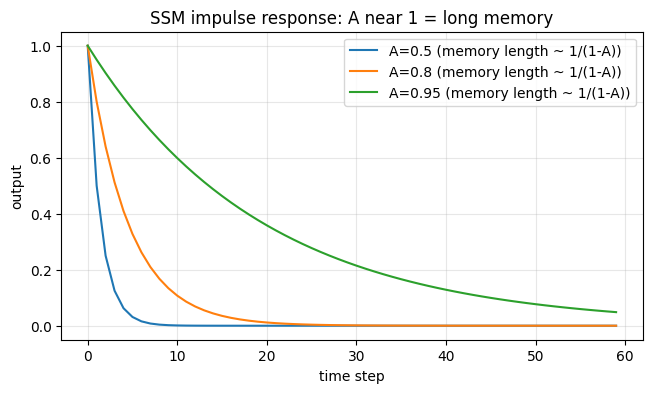

In [5]:
# A diagonal linear SSM: each state dimension is a leaky memory with its own decay.
impulse = np.zeros(60)
impulse[0] = 1.0
fig, ax = plt.subplots(figsize=(7.5, 4))
for a in [0.5, 0.8, 0.95]:
    y = linear_ssm_scan(impulse, A_diag=[a], B=[1.0], C=[1.0])
    ax.plot(y, label=f"A={a} (memory length ~ 1/(1-A))")
ax.set_xlabel("time step"); ax.set_ylabel("output")
ax.set_title("SSM impulse response: A near 1 = long memory"); ax.grid(alpha=0.3); ax.legend()
plt.show()

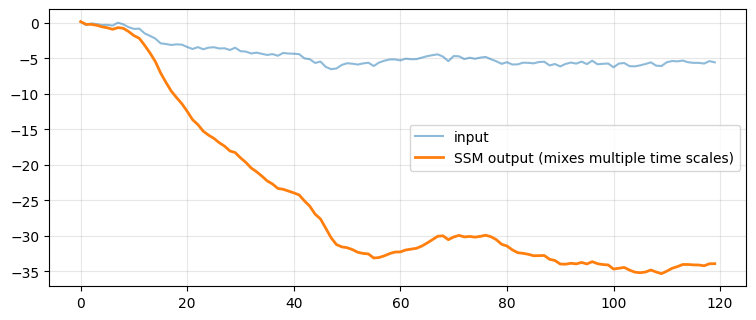

cost is O(T * state_dim): linear in sequence length, unlike O(T^2) attention.


In [6]:
# Multi-state SSM as a sequence mixer: it produces a smoothed, memory-laden output.
set_seed(0)
x_seq = np.cumsum(rng.standard_normal(120)) * 0.3        # a drifting input signal
y_seq = linear_ssm_scan(x_seq, A_diag=[0.9, 0.6, 0.3], B=[1.0, 1.0, 1.0], C=[0.5, 0.3, 0.2])
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(x_seq, alpha=0.5, label="input")
ax.plot(y_seq, lw=2, label="SSM output (mixes multiple time scales)")
ax.legend(); ax.grid(alpha=0.3)
plt.show()
print("cost is O(T * state_dim): linear in sequence length, unlike O(T^2) attention.")

## 5. トレードオフのまとめ

| 手法 | コスト | 近似? | 強み / 弱み |
|---|---|---|---|
| 標準注意(07 章) | $O(T^2)$ | 厳密 | 全対全の関係を捉える / 長系列で重い |
| FlashAttention | $O(T^2)$ 計算・$O(T)$ メモリ | **厳密** | 同じ結果で省メモリ・高速 / 実装が高度 |
| 線形注意 | $O(T)$ | 近似 | 速い / 表現力が落ちることがある |
| SSM (S4/Mamba) | $O(T)$ | (別モデル) | 長期依存・並列スキャン / 全対全は苦手 |

実務の指針:

- まず **FlashAttention**(無料の高速化、PyTorch の SDPA が自動利用)
- 超長系列(数万トークン)では **線形注意 / SSM** を検討
- SSM は音声・ゲノム・長文など「非常に長い系列」で注目株

## 6. まとめ

- 注意の $O(T^2)$ がコンテキスト長の壁。実測でも $T^2$ スケールを確認した。
- **FlashAttention** は数式を変えずに IO を最適化する厳密手法(PyTorch SDPA が自動採用)。
- **線形注意** は softmax を特徴写像に替えて $O(T)$ にする近似。
- **SSM (Mamba)** は線形再帰で長期依存を $O(T)$ で扱う、注意とは別系統の現代的アプローチ。

## 7. Exercises

1. §1 の計測を $T = 4096$ まで伸ばし、$O(T^2)$ の傾きが保たれるか確認せよ(メモリに注意)。
2. 線形注意と厳密注意の差を、系列長 $T$ を変えながら測れ。$T$ が大きいほど差はどうなるか。
3. SSM の `A_diag` を 0.99 にすると記憶長がどれだけ伸びるか、インパルス応答で確認せよ。
4. SSM の状態次元を 1 / 4 / 16 と変え、出力の表現力(複数時間スケールの混合)を比べよ。
5. (発展)`F.scaled_dot_product_attention` を `is_causal=True` で呼び、因果マスク版が
   素朴な実装(07 章)と一致することを確認せよ。

## 線形 SSM の記憶長(インタラクティブ)

対角線形 SSM のインパルス応答は $A_{\mathrm{diag}}^{\,t}$。減衰 $A_{\mathrm{diag}}$ を上げるほど応答が長く尾を引く —— これが状態空間モデルの「記憶の長さ」を決める。

In [7]:
import plotly.io as pio
from nn_textbook import plotting as viz

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = viz.plotly_ssm_impulse()
fig.show()